In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import os

# Add work directory to path
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')
import GWfuncs
import loglike_timemax
import loglike_timemax_Xonly
import loglike_pure


# Import from few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
import few

# Tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu=True
force_backend = 'cuda12x'
# Inspiral kwargs
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

# Amplitude kwargs
amplitude_kwargs = {
    "force_backend": force_backend
}

# Ylm kwargs
Ylm_kwargs = {
    "force_backend": force_backend,
}

# Sum kwargs
sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

# Create waveform generators
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)



In [ ]:
# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

In [3]:
#2 yr
T = 24/12 
dt = 10
gwf = GWfuncs.GravWaveAnalysis(T, dt)

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_tm = loglike_timemax.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=True,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

Initializing LogLike...
Delta_T for mode selection: 12623.259905418237 seconds
Generating modes at initialization...
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Numbe

In [4]:
print('Initializing LogLike...')
loglike_tmX = loglike_timemax_Xonly.LogLike(
    params_star, waveform_gen_comb, gwf,
    verbose=False, waveform_gen_sep=waveform_gen_sep,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing LogLike...


In [6]:
print('Initializing LogLike...')
loglike_p = loglike_pure.LogLike(
    params_star, waveform_gen_comb, gwf,
    verbose=False, waveform_gen_sep=waveform_gen_sep,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing LogLike...


In [7]:
# def standard_lnL(params, data, gwf, waveform_gen_comb,
#                  xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0):

#     params = np.asarray(params)

#     def eval_one(x):
#         try:
#             logm1, logm2, a, p0, e0 = x
#             m1 = 10**logm1
#             m2 = 10**logm2

#             # Generate full combined template waveform
#             template_td = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist,
#                                              qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
#                                              T=2, dt=gwf.dt)


#             # Compute residual
#             residual = data - template_td
#             residual_fd = gwf.freq_wave(residual)

#             # Compute -0.5*<d-h|d-h>
#             lnL = -0.5 * gwf.inner(residual_fd, residual_fd)

#             return lnL
#         except Exception as e:
#             print(f"Error in standard_lnL: {e}")
#             return float('-inf')

#     if params.ndim == 1:
#         return eval_one(params)

#     out = np.zeros(params.shape[0], dtype=float)
#     for i in range(params.shape[0]):
#         out[i] = eval_one(params[i])
#     return out

In [8]:
def logden_tm(params):
      logm1, logm2, a, p0, e0 = params
      return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])))

In [9]:
def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])))

In [10]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])))

In [11]:
logden_pure(param_true), logden_tm(param_true), logden_tmX(param_true)

Evaluating log-likelihood at parameters: [1.00000000e+06 1.00000000e+01 7.00000000e-01 9.00000000e+00
 4.00000000e-01 1.00000000e+00 1.80000000e+00 3.14159265e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.00000000e-01
 0.00000000e+00 5.00000000e-01]
Using selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Waveform amplitudes (time-maximized):
  Mode 0: max(|h|) = 6.827727343128059e-23, <hf|hf>_timemax = 31.257693790946657, rho = 5.590858054981065
  Mode 1: max(|h|) = 1.4859108542747241e-22, <hf|hf>_timemax = 338.523888813053, rho = 18.399018691578444
  Mode 2: max(|h|) = 9.044595556128708e-23, <hf|hf>_t

(32.337991867325975, 32.33698013292318, 32.33799186732557)

In [ ]:
param_idx = 1  # logm2
true_val = param_true[param_idx]

param_range = np.sort(np.append(np.linspace(0.99999,1.00001, 100), true_val))

f_stats_tm   = np.zeros(len(param_range))
f_stats_tmX   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
# lnL_vals     = np.zeros(len(param_range))

m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_tmX[i]   = logden_tmX(p)
    f_stats_pure[i] = logden_pure(p)
    # lnL_vals[i]     = standard_lnL(p, loglike_tm.signal, gwf, waveform_gen_comb,
    #                                 xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

Evaluating log-likelihood at parameters: [1.00000000e+06 9.99976974e+00 7.00000000e-01 9.00000000e+00
 4.00000000e-01 1.00000000e+00 1.80000000e+00 3.14159265e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.00000000e-01
 0.00000000e+00 5.00000000e-01]
Using selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Waveform amplitudes (time-maximized):
  Mode 0: max(|h|) = 6.82602907025124e-23, <hf|hf>_timemax = 31.243268203755008, rho = 5.589567801159139
  Mode 1: max(|h|) = 1.4857342490127106e-22, <hf|hf>_timemax = 338.44734349349955, rho = 18.39693842718129
  Mode 2: max(|h|) = 9.043049601250479e-23, <hf|hf>_t

In [29]:
# # Normalize computed F-stat to peak at 0
# f_stats_tm_norm = f_stats_tm - np.max(f_stats_tm)
# f_stats_pure_norm = f_stats_pure - np.max(f_stats_pure)

# lnL_norm = lnL_vals - np.max(lnL_vals)

In [30]:
f_stats_tm

array([16.61693361, 17.2722478 , 17.79309507, 18.16662566, 18.38111036,
       18.4540108 , 18.37236296, 18.14665405, 17.7829485 , 17.29853616,
       16.70891532, 16.0297591 , 15.26936479, 14.43946216, 13.56490744,
       12.65698431, 11.74871404, 10.84065095,  9.94964013,  9.09045852,
        8.2840742 ,  7.53029722,  6.84711473,  6.23765006,  5.70687493,
        5.25912935,  4.88552986,  4.90268063,  4.91908539,  4.88087856,
        4.85841032,  5.42136111,  5.98262697,  6.51758808,  7.22908853,
        8.59090839, 10.11249202, 11.7952688 , 13.63338965, 15.60853672,
       17.71302165, 19.88961081, 22.07643252, 24.24130941, 26.27867845,
       28.11546498, 29.71078226, 30.96640956, 31.83839624, 32.28372378,
       32.33698013, 32.28205519, 31.83991731, 30.96681565, 29.70823926,
       28.11574716, 26.27817786, 24.2412636 , 22.0759068 , 19.88875943,
       17.71241616, 15.60776888, 13.63359976, 11.79464959, 10.11203856,
        8.59096879,  7.22873829,  6.51684592,  5.9819615 ,  5.42

In [31]:
f_stats_tmX

array([ 0.65471558,  0.66981754,  0.67679462,  0.67910544,  0.68030252,
        0.68270191,  0.68534853,  0.68483792,  0.67734485,  0.66019464,
        0.63283415,  0.59686525,  0.55557158,  0.51407397,  0.47691016,
        0.44604381,  0.42074939,  0.3973331 ,  0.37194396,  0.34181134,
        0.30679646,  0.2690266 ,  0.2335898 ,  0.20483037,  0.18522021,
        0.17468232,  0.17081426,  0.18153132,  0.18849473,  0.1844231 ,
        0.17087405,  0.1703747 ,  0.16817604,  0.17275753,  0.19741923,
        0.26338356,  0.36197413,  0.47629149,  0.55870514,  0.5631549 ,
        0.50330682,  0.44888478,  0.48321633,  0.75040543,  1.74341104,
        5.08085635, 13.51933875, 25.22494323, 31.84072065, 32.47251811,
       32.33799187, 32.42963632, 31.95846236, 25.84190606, 14.24949302,
        5.4638833 ,  1.87554315,  0.7932444 ,  0.49877695,  0.4549725 ,
        0.50641133,  0.56776583,  0.56697814,  0.48645241,  0.3708751 ,
        0.26953345,  0.20105567,  0.17484008,  0.16936531,  0.17

In [32]:
f_stats_pure

array([ 0.05793316,  0.05670448,  0.05480022,  0.05332855,  0.05321908,
        0.05493115,  0.05830418,  0.06256291,  0.06652475,  0.06900409,
        0.06927756,  0.06743605,  0.06446241,  0.06191163,  0.06130668,
        0.06357562,  0.06869046,  0.07546421,  0.08161764,  0.08445542,
        0.08225473,  0.07562267,  0.06751218,  0.0616824 ,  0.06106901,
        0.06709862,  0.07923094,  0.09388148,  0.1039814 ,  0.10220146,
        0.08737899,  0.06674597,  0.05000918,  0.04329229,  0.04955351,
        0.07118328,  0.10737263,  0.14464606,  0.15591414,  0.12791275,
        0.08355849,  0.05445683,  0.05653218,  0.12621756,  0.48340119,
        2.19796535,  8.25449735, 19.7205186 , 29.17958788, 32.16154936,
       32.33799187, 32.1190751 , 29.28743387, 20.20269462,  8.70013118,
        2.36356569,  0.52000573,  0.13341681,  0.05835727,  0.05520825,
        0.08409318,  0.12897651,  0.15822037,  0.14770611,  0.10997766,
        0.07281773,  0.05045546,  0.04382635,  0.05039375,  0.06

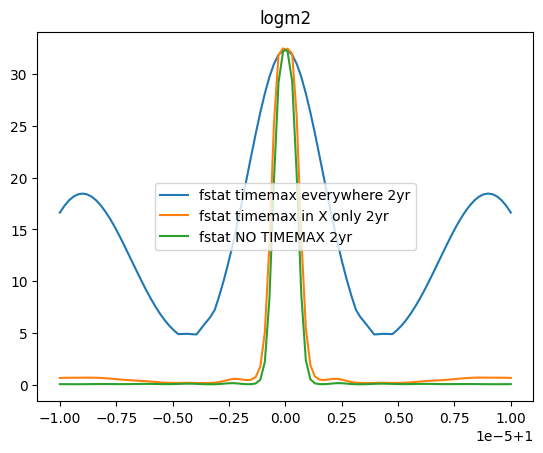

In [33]:
plt.plot(param_range, f_stats_tm, label='fstat timemax everywhere 2yr')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only 2yr')

plt.plot(param_range, f_stats_pure, label='fstat NO TIMEMAX 2yr')

# plt.plot(param_range, lnL_vals, label='lnL cond 2 yr')
# plt.axvline(param_range[88], color='k', linestyle='--', label='Drop fstat')
# plt.ylim(-5,0.01)
# plt.xlim(0.99999,1.00001)
plt.title('logm2')
plt.legend()
plt.show()